In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# EV Battery Degradation Analysis: NMC vs. LFP Chemistries

## 1. Project structure and Introduction

### 1.1 The EV Battery Landscape

Currently, the market is dominated by two lithium-ion battery chemistries: **Nickel Manganese Cobalt (NMC)** and **Lithium Iron Phosphate (LFP)**.

### Battery Chemistry Comparison:

* **NMC (Nickel Manganese Cobalt):**
    * **Pros:** High energy density (longer driving range), better performance in cold climates.
    * **Cons:** Shorter cycle life, higher cost, lower thermal stability.
* **LFP (Lithium Iron Phosphate):**
    * **Pros:** Exceptional longevity (more charge cycles), lower cost, superior thermal stability (safety).
    * **Cons:** Lower energy density (heavier for the same range), slower performance in extreme cold.

### 1.2 Project Overview
This project aims to compare the degradation behavior of NMC and LFP battery chemistries using data science workflows. By analyzing factors such as charging speed, temperature, and usage cycles, we seek to visualize how these two technologies age differently over time.

### 1.3 Objectives
* **Comparative Analysis:** Evaluate the State of Health (SoH) and capacity retention of NMC and LFP batteries.
* **Factor Impact:** Analyze how external factors (temperature, discharge rates, fast-charging) affect degradation in both chemistries.
* **Predictive Insights:** Identify patterns in internal resistance growth and capacity loss.

### 1.4 Data Sources and Methodology
The project utilizes two independent synthetic datasets to provide a multi-layered view of battery health:
1.  **Vehicle-Level Data ([EV Battery Degradation and Charge](https://www.kaggle.com/datasets/bertnardomariouskono/electric-vehicle-ev-battery-degradation-and-charge)):** Focuses on high-level vehicle metrics like age, driving style, and fast-charging ratios across different car models.
2.  **Cycle-Level Data ([Battery Failure Surfaces](https://www.kaggle.com/datasets/niladriroy0/battery-failure-surfaces)):** Provides granular, cycle-by-cycle measurements of internal resistance and capacity retention, simulating laboratory testing conditions.

### 1.5 Important Disclaimer & Limitations
**Note:** This analysis is based on **synthetic datasets** generated for educational and research simulation purposes. This project is a comparison of two specific synthetic data sources and should **not** be interpreted as a factual, real-world verdict on the ultimate performance of NMC or LFP chemistries. The conclusions reached here are representative of the trends within these specific datasets and are intended to demonstrate data science methodologies rather than provide a definitive engineering benchmark.

## 2. Data Acquisition and Initial Processing
In this section, we load our two independent datasets, inspect their structures, and perform initial cleaning to ensure consistent naming conventions for our battery chemistry comparison.

In [30]:
# Load the datasets
vehicle_data_raw = pd.read_csv('data/ev_battery_degradation_v1.csv')
cycle_data_raw = pd.read_csv('data/battery_failure_surfaces.csv')

In [31]:
vehicle_data_raw

,Vehicle_ID,Car_Model,Battery_Type,Battery_Capacity_kWh,Vehicle_Age_Months,Total_Charging_Cycles,Avg_Temperature_C,Fast_Charge_Ratio,Avg_Discharge_Rate_C,Driving_Style,Internal_Resistance_Ohm,SoH_Percent,Battery_Status
0,1fb46ae8,Tesla Model 3,NMC,75.0,41,390,21.5,0.51,2.22,Aggressive,0.0362,94.60,Healthy
1,b7ef35aa,Tesla Model 3,NMC,75.0,29,401,18.0,0.62,1.34,Aggressive,0.0333,95.68,Healthy
2,76cb49e0,Ford Mustang Mach-E,NMC,88.0,71,941,18.4,0.78,1.48,Conservative,0.0526,89.80,Healthy
3,456a7aef,Ford Mustang Mach-E,NMC,88.0,57,378,10.8,0.61,0.72,Moderate,0.0314,96.29,Healthy
4,bd758049,Tesla Model 3,NMC,75.0,58,239,30.3,0.89,1.48,Conservative,0.0297,96.75,Healthy
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,19f0cbd6,Tesla Model 3,NMC,75.0,91,1287,31.3,0.83,2.00,Moderate,0.0668,84.57,Healthy
9996,f157c5aa,Tesla Model 3,NMC,75.0,90,767,34.4,0.49,2.47,Moderate,0.0444,91.62,Healthy
9997,3c549739,BYD Atto 3,LFP,60.0,93,525,23.3,0.45,2.18,Moderate,0.0277,96.94,Healthy
9998,a6c88d13,Ford Mustang Mach-E,NMC,88.0,14,161,19.1,0.87,2.31,Aggressive,0.0268,97.17,Healthy


In [32]:
cycle_data_raw

,cell_chemistry,cycle,charge_rate_C,discharge_rate_C,cell_temperature_C,internal_resistance_mOhm,capacity_retention_%,cumulative_high_temp_cycles,fast_charge_exposure_cycles,irreversible_damage_index,thermal_runaway_risk_score
0,Li-ion NMC,0,1.311626,2.401429,33.544339,33.923862,99.972475,0,0,0.0,0.02
1,Li-ion NMC,1,1.311626,2.401429,33.359694,33.947258,99.944950,0,0,0.0,0.02
2,Li-ion NMC,2,1.311626,2.401429,33.787926,33.970654,99.917425,0,0,0.0,0.02
3,Li-ion NMC,3,1.311626,2.401429,32.878808,33.994050,99.889901,0,0,0.0,0.02
4,Li-ion NMC,4,1.311626,2.401429,32.150625,34.017447,99.862376,0,0,0.0,0.02
...,...,...,...,...,...,...,...,...,...,...,...
477248,Solid-State,495,0.641363,0.500000,28.683184,56.911233,93.315506,0,0,0.0,0.03
477249,Solid-State,496,0.641363,0.500000,28.517270,56.919234,93.306093,0,0,0.0,0.03
477250,Solid-State,497,0.641363,0.500000,28.104930,56.927236,93.296679,0,0,0.0,0.03
477251,Solid-State,498,0.641363,0.500000,26.495163,56.935237,93.287266,0,0,0.0,0.03


In [29]:
# 2.1 Load the datasets
vehicle_data = pd.read_csv('data/ev_battery_degradation_v1.csv')
cycle_data = pd.read_csv('data/battery_failure_surfaces.csv')

# 2.2 Unify Chemistry Labels
# Ensuring both use 'NMC' and 'LFP' and filtering out 'Solid-State'
cycle_data['cell_chemistry'] = cycle_data['cell_chemistry'].replace({'Li-ion NMC': 'NMC'})
target_chemistries = ['NMC', 'LFP']
vehicle_data = vehicle_data[vehicle_data['Battery_Type'].isin(target_chemistries)].copy()
cycle_data = cycle_data[cycle_data['cell_chemistry'].isin(target_chemistries)].copy()

# 2.3 Unit Conversion: Ohm to mOhm for Vehicle Data
# 1 Ohm = 1000 mOhm
vehicle_data['Internal_Resistance_Ohm'] = vehicle_data['Internal_Resistance_Ohm'] * 1000

# 2.4 Standardize Column Names across both datasets
# vehicle_data renames
vehicle_data = vehicle_data.rename(columns={
    'Battery_Type': 'Battery_Chemistry',
    'Total_Charging_Cycles': 'Charging_Cycles',
    'SoH_Percent': 'SoH (%)',
    'Internal_Resistance_Ohm': 'Internal_Resistance_mOhm'
})

# cycle_data renames
cycle_data = cycle_data.rename(columns={
    'cell_chemistry': 'Battery_Chemistry',
    'cycle': 'Charging_Cycles',
    'capacity_retention_%': 'SoH (%)',
    'internal_resistance_mOhm': 'Internal_Resistance_mOhm'
})

# 2.5 Data Selection (Dropping Unused Columns)
# Removing columns that are out of scope for our specific health comparison
vehicle_cols_to_drop = [
    'Vehicle_ID', 'Car_Model', 'Battery_Capacity_kWh', 
    'Vehicle_Age_Months', 'Driving_Style', 'Battery_Status'
]
vehicle_data = vehicle_data.drop(columns=vehicle_cols_to_drop)

cycle_cols_to_drop = [
    'cumulative_high_temp_cycles', 'fast_charge_exposure_cycles', 
    'irreversible_damage_index', 'thermal_runaway_risk_score'
]
cycle_data = cycle_data.drop(columns=cycle_cols_to_drop)

# 2.6 Numerical Formatting
# Rounding all numeric columns to 2 decimal places for clarity
vehicle_data = vehicle_data.round(2)
cycle_data = cycle_data.round(2)

In [33]:
vehicle_data

,Battery_Chemistry,Charging_Cycles,Avg_Temperature_C,Fast_Charge_Ratio,Avg_Discharge_Rate_C,Internal_Resistance_mOhm,SoH (%)
0,NMC,390,21.5,0.51,2.22,36.2,94.60
1,NMC,401,18.0,0.62,1.34,33.3,95.68
2,NMC,941,18.4,0.78,1.48,52.6,89.80
3,NMC,378,10.8,0.61,0.72,31.4,96.29
4,NMC,239,30.3,0.89,1.48,29.7,96.75
...,...,...,...,...,...,...,...
9995,NMC,1287,31.3,0.83,2.00,66.8,84.57
9996,NMC,767,34.4,0.49,2.47,44.4,91.62
9997,LFP,525,23.3,0.45,2.18,27.7,96.94
9998,NMC,161,19.1,0.87,2.31,26.8,97.17


In [34]:
cycle_data

,Battery_Chemistry,Charging_Cycles,charge_rate_C,discharge_rate_C,cell_temperature_C,Internal_Resistance_mOhm,SoH (%)
0,NMC,0,1.31,2.40,33.54,33.92,99.97
1,NMC,1,1.31,2.40,33.36,33.95,99.94
2,NMC,2,1.31,2.40,33.79,33.97,99.92
3,NMC,3,1.31,2.40,32.88,33.99,99.89
4,NMC,4,1.31,2.40,32.15,34.02,99.86
...,...,...,...,...,...,...,...
287217,LFP,495,0.56,1.92,28.93,52.42,89.17
287218,LFP,496,0.56,1.92,28.96,52.44,89.15
287219,LFP,497,0.56,1.92,29.44,52.45,89.13
287220,LFP,498,0.56,1.92,28.92,52.47,89.12


## 3. Exploratory Data Analysis (EDA)
### 3.1 Data Profile and Balance
Before analyzing degradation, we must understand the composition of our datasets. This section explores the distribution of battery chemistries and the range of usage (charging cycles) captured in both sources. This ensures our comparison is based on a balanced and representative set of samples.

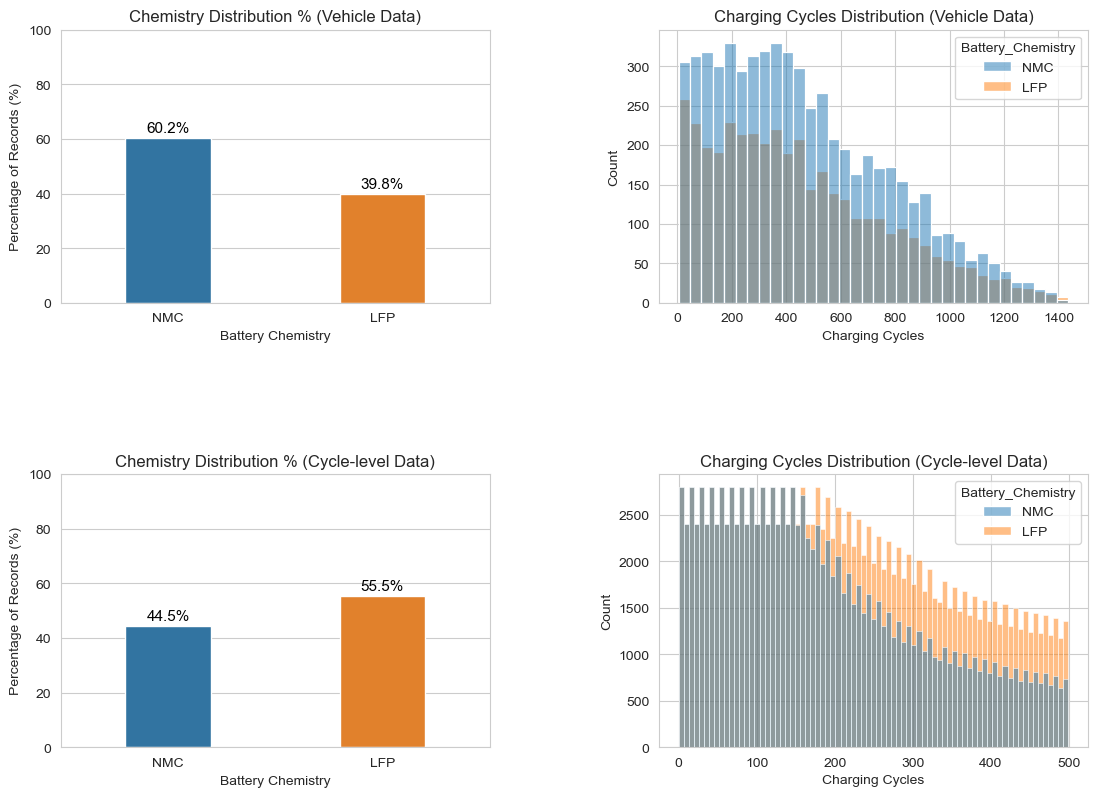

In [81]:
# 1. Configuration
chem_palette = {'NMC': '#1f77b4', 'LFP': '#ff7f0e'}
chem_order = ['NMC', 'LFP']
cycle_label = "Charging Cycles"
chem_axis_label = "Battery Chemistry"

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
sns.set_style("whitegrid")

# --- 1. VEHICLE-LEVEL DATASET ---

# 1.1 Percentage Distribution (Vehicle)
vehicle_dist = vehicle_data['Battery_Chemistry'].value_counts(normalize=True).mul(100).reset_index()
vehicle_dist.columns = ['Battery_Chemistry', 'Percentage']

ax1 = sns.barplot(ax=axes[0, 0], data=vehicle_dist, x='Battery_Chemistry', y='Percentage', 
                  palette=chem_palette, hue='Battery_Chemistry', legend=False, 
                  width=0.4, order=chem_order)
axes[0, 0].set_title('Chemistry Distribution % (Vehicle Data)')
axes[0, 0].set_xlabel(chem_axis_label)
axes[0, 0].set_ylabel('Percentage of Records (%)')
axes[0, 0].set_ylim(0, 100)

for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='center', fontsize=11, color='black', xytext=(0, 7), 
                 textcoords='offset points')

# 1.2 Cycle Distribution (Vehicle)
sns.histplot(ax=axes[0, 1], data=vehicle_data, x='Charging_Cycles', hue='Battery_Chemistry', 
             palette=chem_palette, hue_order=chem_order)
axes[0, 1].set_title(f'{cycle_label} Distribution (Vehicle Data)')
axes[0, 1].set_xlabel(cycle_label)


# --- 2. CYCLE-LEVEL DATASET ---

# 2.1 Percentage Distribution (Cycle-level)
cycle_dist = cycle_data['Battery_Chemistry'].value_counts(normalize=True).mul(100).reset_index()
cycle_dist.columns = ['Battery_Chemistry', 'Percentage']

ax2 = sns.barplot(ax=axes[1, 0], data=cycle_dist, x='Battery_Chemistry', y='Percentage', 
                  palette=chem_palette, hue='Battery_Chemistry', legend=False, 
                  width=0.4, order=chem_order)
axes[1, 0].set_title('Chemistry Distribution % (Cycle-level Data)')
axes[1, 0].set_xlabel(chem_axis_label)
axes[1, 0].set_ylabel('Percentage of Records (%)')
axes[1, 0].set_ylim(0, 100)

for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='center', fontsize=11, color='black', xytext=(0, 7), 
                 textcoords='offset points')

# 2.2 Cycle Distribution (Cycle-level)
sns.histplot(ax=axes[1, 1], data=cycle_data, x='Charging_Cycles', hue='Battery_Chemistry', 
             palette=chem_palette, hue_order=chem_order)
axes[1, 1].set_title(f'{cycle_label} Distribution (Cycle-level Data)')
axes[1, 1].set_xlabel(cycle_label)

plt.tight_layout(pad=8)
plt.show()

**Key Conclusions:** From our initial data exploration, we can draw several key observations that will guide the rest of our analysis:

1. **Dataset Balance:** Both datasets provide a relatively balanced representation of NMC and LFP batteries. This allows us to make direct comparisons without significant bias from one battery type dominating the sample size.
2. **Usage Coverage:**
    - **Vehicle Data** effectively simulates a wide range of operational conditions, with cycle counts typically peaking in the mid-range. 
    - **Cycle-level Data** represents a different testing profile, likely simulating lab conditions where batteries are pushed to specific cycle limits.
4. **Validation of Comparison Window:** Crucially, both chemistries are represented across a similar range of usage:
   - In the **Vehicle Dataset**, both NMC and LFP batteries show usage from near-zero up to approximately **1,400 cycles**.
   - In the **Cycle-level Dataset**, both chemistries follow an identical testing window from **0 to 499 cycles**.
   This symmetry is vital as it ensures our subsequent degradation analysis is fair and not biased by one battery type being significantly "older" than the other in the data.

### 3.2 Degradation Trends: SoH vs. Cycles
In this section, we directly compare the degradation behavior of NMC and LFP chemistries. We use regression plots to fit linear trendlines to the State of Health data against the Charging Cycles. By observing the slope of these lines across both simulated environments (Vehicle vs. Lab), we can visualize how usage affects health over the battery's lifecycle.

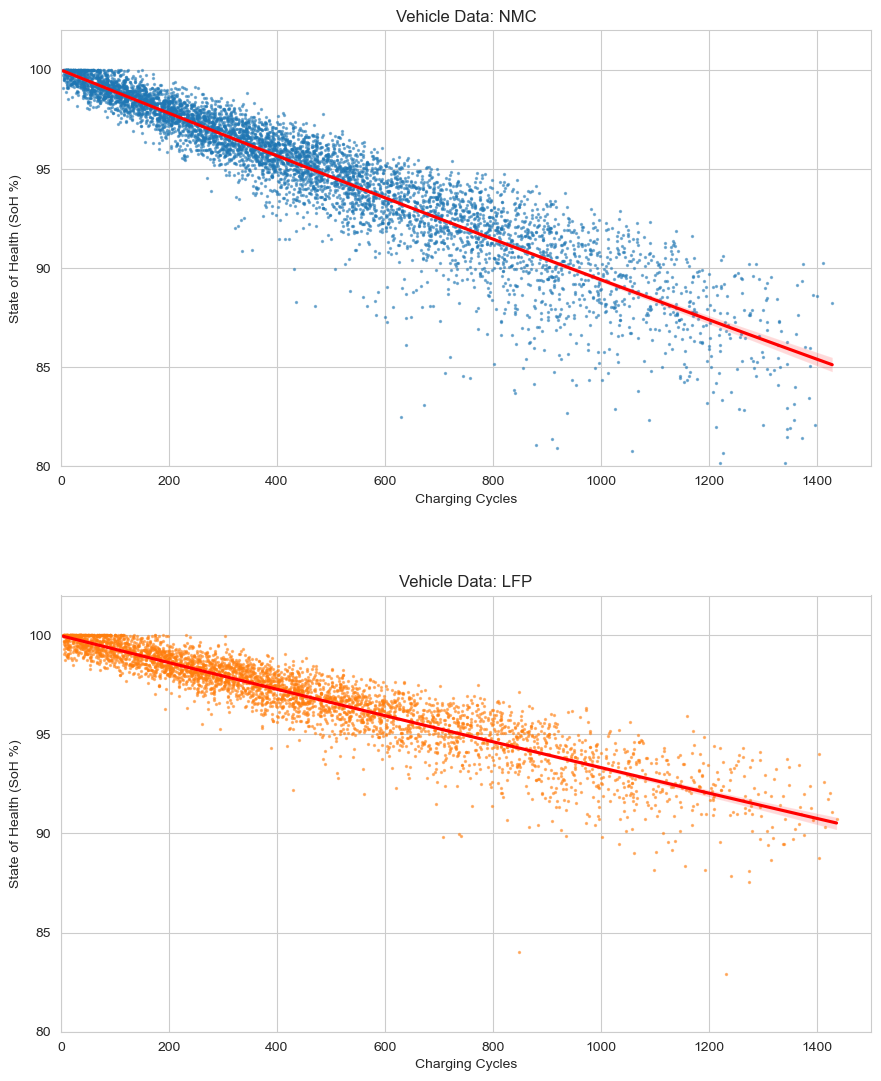

In [67]:
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# 1. NMC
sns.regplot(ax=axes[0], data=df_vehicle_nmc, x='Charging_Cycles', y='SoH (%)', 
            color=chem_palette['NMC'], 
            scatter_kws={'alpha': 0.5, 's': 2}, 
            line_kws={'color': 'red', 'label': 'Polynomial Trend'},
            order=2) # 2nd order polynomial
axes[0].set_title('Vehicle Data: NMC')
axes[0].set_xlim(0, 1500)
axes[0].set_yticks(np.arange(80, 105, 5))
axes[0].set_ylim(80, 102)
axes[0].set_ylabel('State of Health (SoH %)')
axes[0].set_xlabel('Charging Cycles')

# 2. LFP
sns.regplot(ax=axes[1], data=df_vehicle_lfp, x='Charging_Cycles', y='SoH (%)', 
            color=chem_palette['LFP'], 
            scatter_kws={'alpha': 0.5, 's': 2}, 
            line_kws={'color': 'red', 'label': 'Polynomial Trend'},
            order=2)
axes[1].set_title('Vehicle Data: LFP')
axes[1].set_xlim(0, 1500)
axes[1].set_yticks(np.arange(80, 105, 5))
axes[1].set_ylim(80, 102)
axes[1].set_ylabel('State of Health (SoH %)')
axes[1].set_xlabel('Charging Cycles')

plt.tight_layout(pad=5.0) 
plt.show()

**Key Conclusions:** Degradation Morphology & Chemistry Comparison

Based on the regression analysis of the vehicle_data, several key insights can be drawn regarding the simulated performance of **NMC** vs. **LFP** chemistries:

* **Chemistry Resilience & Longevity** Both chemistries exhibit a clear correlation between increased charging cycles and State of Health (SoH) decline. However, the LFP chemistry demonstrates a distinct longevity advantage. After approximately 1,400 cycles, LFP maintains an SoH above 90%, whereas NMC drops to approximately 85%. This aligns with the known cycle-life superiority of Lithium Iron Phosphate in real-world applications.

* **Linearity vs. Physical Behavior** The trendlines in this dataset are strictly linear. In actual physical battery systems, degradation typically follows a non-linear "S-curve," characterized by an initial stabilization drop within the first 50–100 cycles (often reaching ~96% SoH) before entering a stable linear phase. The straight-line plots here suggest the synthetic dataset utilizes a simplified linear degradation coefficient rather than a multi-stage chemical aging model.

* **Divergence of Health (Data Dispersion)** An important visual observation is the distribution of the scatter points. At the beginning of the lifecycle (0–200 cycles), the data points are tightly "packed" around the trendline. As cycles increase, the points become significantly more dispersed. This suggests that degradation factors are cumulative; the impact of variables like ambient temperature or fast-charging build up over time, leading to a wider range of possible SoH outcomes as the battery ages.

* **Optimistic SoH Retention** The final health values (85–90% at 1,400 cycles) represent a highly optimistic scenario compared to empirical field statistics. In typical real-world conditions, NMC cells often approach the 70–80% "End of Life" (EoL) threshold at this cycle count. This discrepancy is likely a mathematical byproduct of the missing "initial drop" phase and the absence of non-linear "knee" points where degradation usually accelerates.

* **Data Model Validity** While the synthetic nature of the data simplifies the complex chemical process of battery aging, the relative performance gap between the two chemistries remains a valid basis for comparative study. The simulation effectively captures the ratio of degradation between LFP and NMC, even if the absolute SoH values are slightly higher than reality.

### 3.3 Multivariable Interdependencies and Correlation Analysis

Battery degradation is rarely the result of a single isolated factor. While Charging Cycles serve as the primary clock for aging, several interconnected variables accelerate or mediate this process:

* **Operational Factors:** Fast Charging Ratio and Discharge Rate (heavily influenced by driving style) are user-dependent variables that increase the stress on the battery chemistry.
* **Thermal Factors:** Ambient Temperature directly impacts chemical stability. However, temperature is also a byproduct of high discharge rates and fast charging.
* **The "Health Proxy" (Internal Resistance):** Internal Resistance acts as a critical indicator of degradation. It is a dependent variable influenced by cycles, age, and thermal history. As resistance rises, efficiency drops and heat generation increases, creating a feedback loop that further accelerates SoH decline.

The following heatmap visualizes these correlations within the Vehicle dataset, allowing us to see how strongly these factors "move together."

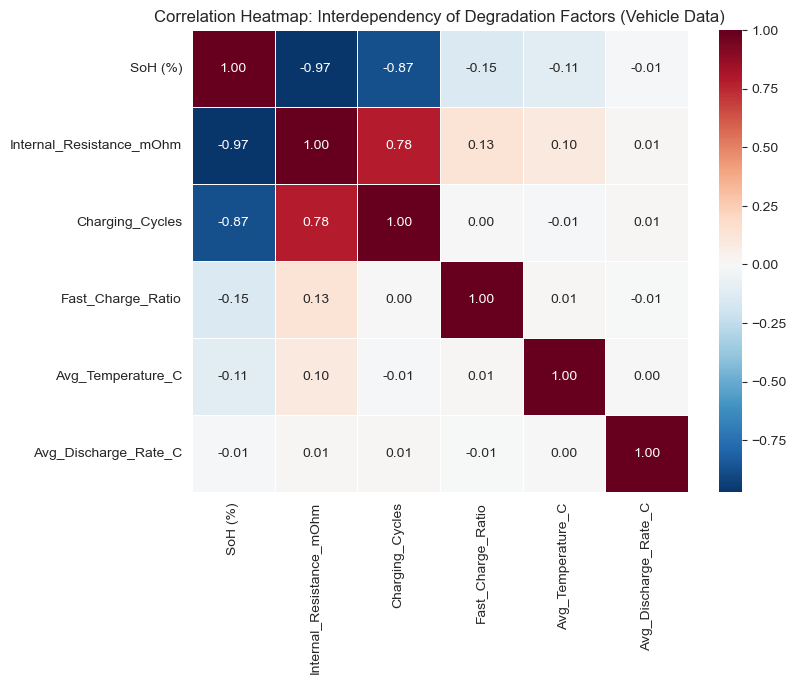

In [88]:
correlation_cols = [
    'SoH (%)', 'Internal_Resistance_mOhm', 'Charging_Cycles', 
    'Fast_Charge_Ratio', 'Avg_Temperature_C', 'Avg_Discharge_Rate_C'
]

vehicle_corr = vehicle_data[correlation_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(vehicle_corr, annot=True, cmap='RdBu_r', center=0, fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap: Interdependency of Degradation Factors (Vehicle Data)')
plt.show()

**Key Conclusions**

* **Dominant Degradation Drivers:** Internal Resistance and Charging Cycles are the most critical predictors of battery health. Their high negative correlation values (-0.97 and -0.87, respectively) indicate that as these metrics increase, the battery's health consistently and significantly drops.

* **The "Cycle-Resistance" Link:** There is a strong positive correlation (0.78) between Charging Cycles and Internal Resistance. This suggests that the physical wear from repeated cycling is a primary cause for the buildup of internal resistance.

* **Minimal Impact Factors:** In this specific dataset, Fast Charging, Temperature, and Discharge Rates have surprisingly little impact on SoH. This might suggest that the vehicles are operated within safe thermal and electrical limits, or that these factors are secondary to the simple "age" (cycles) of the battery.

* **Dataset Limitation vs. Reality (Synthetic Data Note):** In physical battery systems, we typically expect "coupling" (e.g., high fast-charging ratios usually correlate with higher battery temperatures). The 0.00 to 0.01 correlations between Temperature, Discharge Rate, and Fast Charging Ratio suggest that while these features exist in the dataset, the synthetic model may not have applied their impact linearly, or they may be modeled as stochastic (random) noise rather than direct linear trends.

### 3.2.4 Analysis of Chemistry Sensitivity to Cumulative Stressors

A critical observation from the regression analysis is the "Divergence of Health" as the battery ages. By comparing the state of health at different lifecycle stages, we can evaluate the stability and predictability of each chemistry's degradation path within this simulation.

* **Early-Life Convergence:** At the 200-cycle milestone, both NMC and LFP exhibit tightly packed distributions. This indicates that early degradation is highly predictable and primarily governed by the base linear aging model, with very little variance between individual battery units.
* **Late-Life Dispersion:** By the 1,200-cycle milestone, the data points become significantly more scattered. Because our correlation analysis showed a near-zero relationship between SoH and external factors (Temperature, Fast Charging, and Discharge Rate), this dispersion is not directly triggered by those variables. Instead, it suggests a cumulative variance that builds up over time, representing an increase in "degradation uncertainty" as the cycle count increases.

#### Chemistry-Specific Sensitivity: 
* **NMC Sensitivity:** The wider spread in late-life NMC data indicates that this chemistry's health path is more prone to divergence. In this model, NMC exhibits a higher degree of unpredictability as it ages.
* **LFP Robustness:** The relatively tighter grouping of LFP data points suggests a more consistent and stable degradation profile. Even as cumulative variance increases with cycle life, LFP maintains a more predictable path compared to NMC.

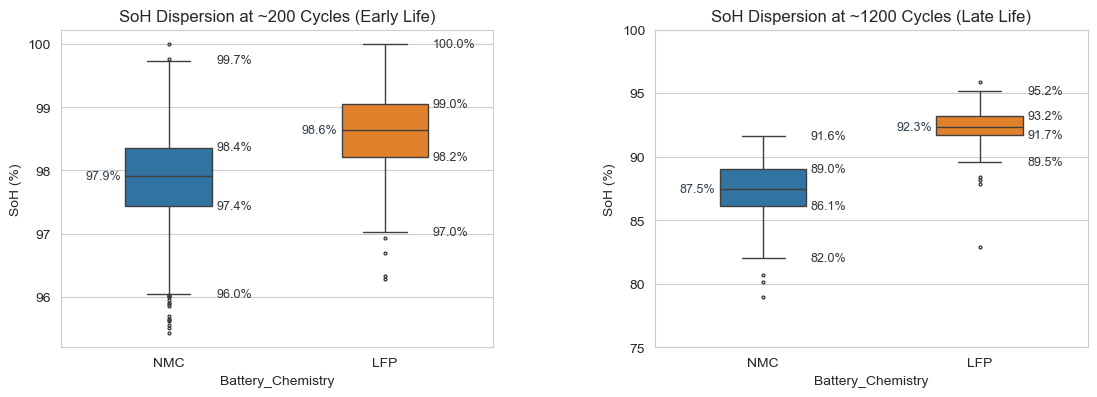

In [145]:
# Create two snapshots in time: Early Life (e.g., 200 cycles) and Late Life (e.g., 1200 cycles)
early_life = vehicle_data[(vehicle_data['Charging_Cycles'] > 150) & (vehicle_data['Charging_Cycles'] < 250)]
late_life = vehicle_data[(vehicle_data['Charging_Cycles'] > 1150) & (vehicle_data['Charging_Cycles'] < 1250)]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

def annotate_boxplot(ax, data, x_col, y_col):
    categories = data[x_col].unique()
    
    for i, cat in enumerate(categories):
        subset = data[data[x_col] == cat][y_col].dropna()
        if subset.empty: continue
        
        median = subset.median()
        q1 = subset.quantile(0.25)
        q3 = subset.quantile(0.75)
        iqr = q3 - q1
        upper_whisker = subset[subset <= q3 + 1.5 * iqr].max()
        lower_whisker = subset[subset >= q1 - 1.5 * iqr].min()
        
        ax.text(i - 0.22, median, f'{median:.1f}%', 
                va='center', ha='right', fontsize=9, color='#2c3e50')
        
        right_stats = {
            'Max': upper_whisker, 
            'Q3': q3, 
            'Q1': q1, 
            'Min': lower_whisker
        }
        
        for label, val in right_stats.items():
            ax.text(i + 0.22, val, f'{val:.1f}%', 
                    va='center', ha='left', fontsize=9, fontweight='normal', color='#333333')

# Plot 1: Early Life Dispersion
sns.boxplot(ax=axes[0], data=early_life, x='Battery_Chemistry', y='SoH (%)', 
            hue='Battery_Chemistry', palette=chem_palette, legend=False, width=0.4, fliersize=2)
axes[0].set_title('SoH Dispersion at ~200 Cycles (Early Life)')
annotate_boxplot(axes[0], early_life, 'Battery_Chemistry', 'SoH (%)')

# Plot 2: Late Life Dispersion
sns.boxplot(ax=axes[1], data=late_life, x='Battery_Chemistry', y='SoH (%)', 
            hue='Battery_Chemistry', palette=chem_palette, legend=False, width=0.4, fliersize=2)
axes[1].set_title('SoH Dispersion at ~1200 Cycles (Late Life)')
axes[1].set_yticks(np.arange(75, 105, 5))
annotate_boxplot(axes[1], late_life, 'Battery_Chemistry', 'SoH (%)')

plt.tight_layout(pad=8)
plt.show()